In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/dpitg/py


In [ ]:
from utils import print_env_info, report_accounting_size

from utils_viz import (
    FIG_WIDTH,
    FIG_HEIGHT,
    SMALL_SIZE,
    MEDIUM_SIZE,
    BIGGER_SIZE,
    plot_sample_pdf_methods,
    viz_sequence_stats
)

from utils_experiments_binomial import (
    BinaryAccounting, 
    stop_decision_multiple_sequences_multiple_methods,
    sequence_to_iteration_stats,
    SEQUENCE_HANDPICKED,
    stats_dict_to_df,
    )

In [ ]:
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [5]:
print_env_info()

Last run: 2026-06-27 10:38:46.244844
Python: 3.10.13
Platform: macOS-13.0-x86_64-i386-64bit
pandas: 2.3.3
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.9
notebook: 7.6.0


# Aux

In [15]:
# used for storing an linking to binary calucations already performed
binary_accounting = BinaryAccounting()

print(binary_accounting.dict_successes_failures_counter, binary_accounting.dict_successes_failures_hdi_limits)
print("-" * 20)
report_accounting_size(binary_accounting)

{} {}
--------------------
Binary Accounting Report
0 elements in 0.00 MBytes)
The binary counter is empty


In [16]:
binary_accounting.successes_failures_to_hdi_limits(10, 20)
binary_accounting.successes_failures_to_hdi_limits(10, 20)
binary_accounting.successes_failures_to_hdi_limits(20, 10)
binary_accounting.successes_failures_to_hdi_limits(11, 22)

display(binary_accounting.dict_successes_failures_counter)
display(pd.DataFrame(binary_accounting.dict_successes_failures_hdi_limits).T)
print("-" * 20)
report_accounting_size(binary_accounting)

{(10, 20): 2, (20, 10): 1, (11, 22): 1}

,,0,1
10,20,0.172628,0.500225
20,10,0.499775,0.827372
11,22,0.179454,0.492656


--------------------
Binary Accounting Report
3 elements in 0.00 MBytes)
Most frequent count value: 30 (appears 2 times (of 3 66.67%))
Max sum 33
e.g, key (11, 22) appears 1 time(s) yiedling (np.float64(0.17945436978149346), np.float64(0.4926564865758776)) HDI limits



# Visualise One Experiment

In [17]:
# True parameter params
θ_true = 0.5
sequence = np.array([int(bit) for bit in SEQUENCE_HANDPICKED])

print(f"True parameter: θ_true = {θ_true}")
print(f"Handpicked sequence of length N={len(sequence):,}: {''.join(map(str, sequence[:20]))}...{''.join(map(str, sequence[-20:]))}")


True parameter: θ_true = 0.5
Handpicked sequence of length N=1,500: 10110100011001000010...11010101111011000110


In [18]:
# Null hypothesis params
rope_min_null = 0.45
rope_max_null = 0.55

In [19]:
# Precision Goal params

ω_goal = 0.08

In [20]:
%%time
# Running a one sequence experiment (M=1)
# On macOS-13.0-x86_64-i386-64bit runs for 6 seconds

df_sequence_stats = sequence_to_iteration_stats(sequence, ω_goal, rope_min_null, rope_max_null, binary_accounting=binary_accounting, iteration_number=None)

print(df_sequence_stats.shape)
df_sequence_stats.tail(10)

(1500, 14)
CPU times: user 5.99 s, sys: 26.5 ms, total: 6.02 s
Wall time: 6.04 s


,decision_iteration,accept,reject_below,reject_above,conclusive,inconclusive,successes,failures,hdi_min,hdi_max,goal_achieved,reject,precision,success_rate
experiment_number,,,,,,,,,,,,,,
1491,1491.0,True,False,False,True,False,762,729,0.485709,0.536431,True,False,0.050722,0.511066
1492,1492.0,True,False,False,True,False,762,730,0.485375,0.536080,True,False,0.050706,0.510724
1493,1493.0,True,False,False,True,False,763,730,0.485711,0.536399,True,False,0.050688,0.511052
1494,1494.0,True,False,False,True,False,764,730,0.486047,0.536717,True,False,0.050670,0.511379
1495,1495.0,True,False,False,True,False,764,731,0.485713,0.536367,True,False,0.050654,0.511037
1496,1496.0,True,False,False,True,False,764,732,0.485380,0.536018,True,False,0.050638,0.510695
1497,1497.0,True,False,False,True,False,764,733,0.485047,0.535669,True,False,0.050622,0.510354
1498,1498.0,True,False,False,True,False,765,733,0.485383,0.535987,True,False,0.050604,0.510681
1499,1499.0,True,False,False,True,False,766,733,0.485717,0.536304,True,False,0.050587,0.511007


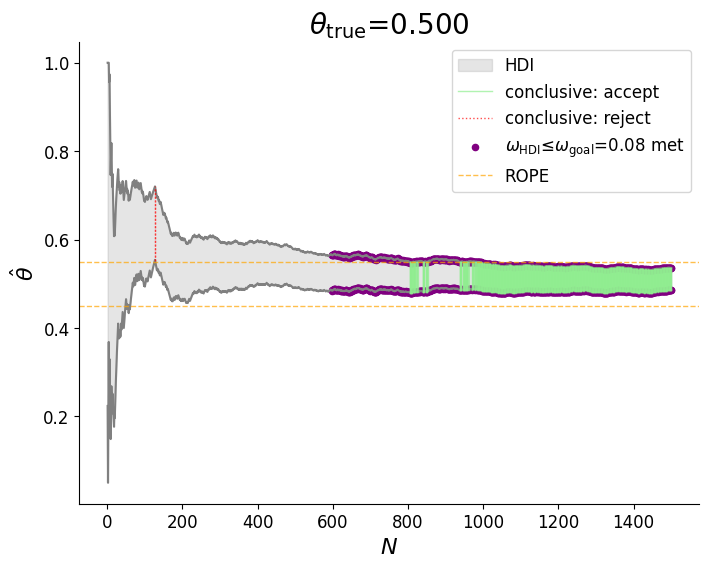

In [21]:
viz_sequence_stats(df_sequence_stats, ω_goal, rope_min_null, rope_max_null, θ_true=θ_true)

In [22]:
experiments = sequence.reshape(1, -1)
experiments.shape

(1, 1500)

In [23]:
method_stats, method_roperesult_iteration  = stop_decision_multiple_sequences_multiple_methods(experiments, rope_min_null, rope_max_null, ω_goal, binary_accounting=binary_accounting)

In [25]:
print(method_stats.keys())
display(pd.DataFrame(method_stats['dpitg']).T)

dict_keys(['pitg', 'dpitg', 'hdi_rope'])


,decision_iteration,accept,reject_below,reject_above,conclusive,inconclusive,successes,failures,hdi_min,hdi_max,precision_goal_achieved
0,804,True,False,False,True,False,414,390,0.480398,0.549429,True


In [28]:
pd.DataFrame(method_roperesult_iteration['dpitg']).T

,1,2,3,4,5,6,7,8,9,10,...,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500
within,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
below,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
above,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
method_df_stats = {method_name: stats_dict_to_df(method_stats[method_name]) for method_name in method_stats}
method_df_stats['dpitg']

,decision_iteration,accept,reject_below,reject_above,conclusive,inconclusive,successes,failures,hdi_min,hdi_max,precision_goal_achieved,reject,precision,success_rate
experiment_number,,,,,,,,,,,,,,
0,804.0,True,False,False,True,False,414,390,0.480398,0.549429,True,False,0.069031,0.514925


0.4850822706487851 0.5650347292260883
0.48039836031907357 0.549429017020994
0.5508244626218102 0.717876210358378


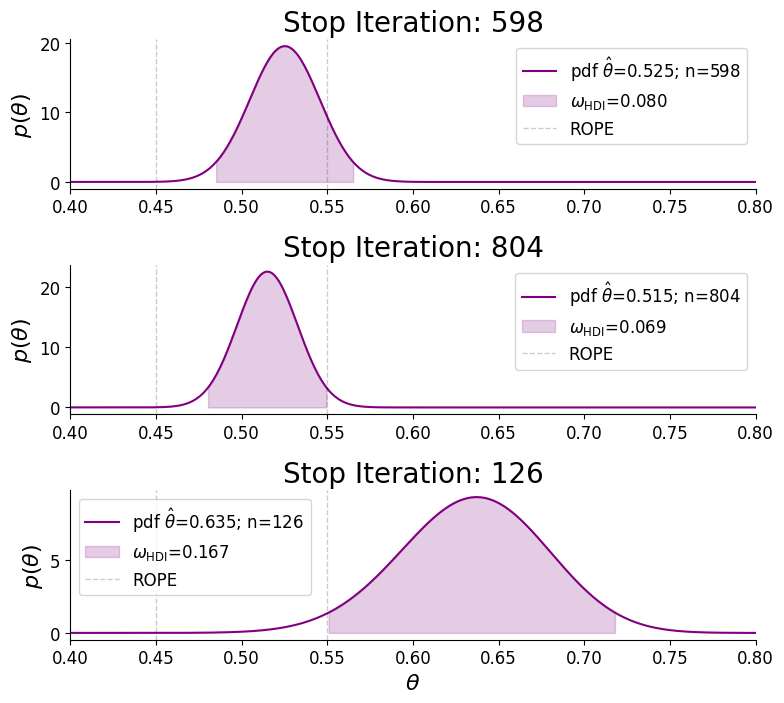

In [30]:
plot_sample_pdf_methods(method_df_stats, 0, rope_min_null, rope_max_null, xlim = (0.4, 0.8), method_names=None)